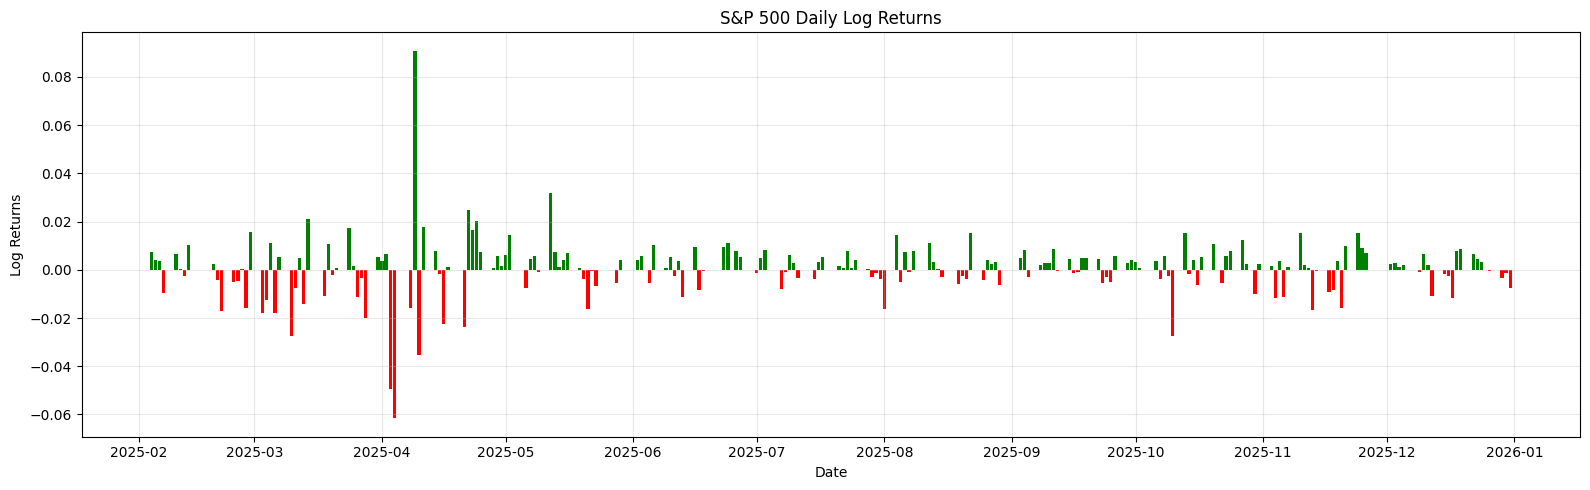

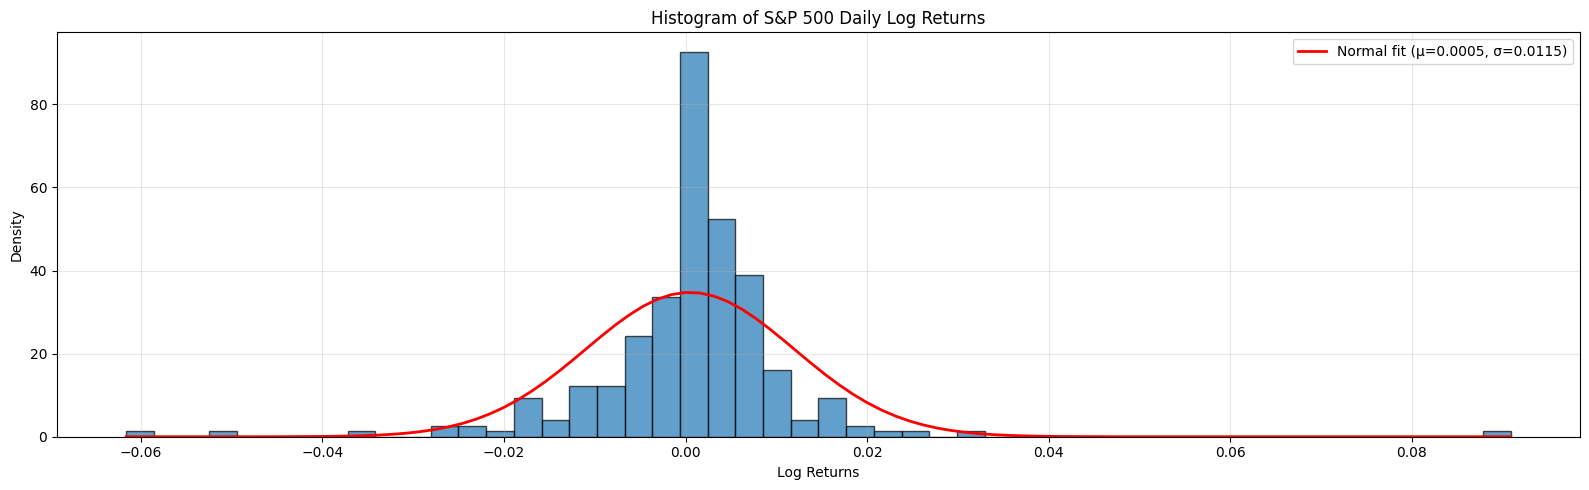

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from project_paths import SPX_MINUTE_FILE

SPX_MINUTE_FILE = SPX_MINUTE_FILE
# Load S&P 500 data
df = pd.read_csv(SPX_MINUTE_FILE, sep=';', header=None, 
                 names=['dt_raw', 'Open_u', 'High_u', 'Low_u', 'Close_u', 'Volume_u'])  # Adjust filename/path as needed

# Ensure date column is datetime and set as index
df['Date'] = pd.to_datetime(df['dt_raw'])
df.set_index('Date', inplace=True)

# Resample to daily data
df_daily = df.resample('D').agg({'Close_u': 'last', 'Volume_u': 'sum'})

# Calculate daily log returns
df_daily['Log_Returns'] = np.log(df_daily['Close_u'] / df_daily['Close_u'].shift(1))

# Create graph with colored bars
plt.figure(figsize=(16, 5))
colors = ['green' if x >= 0 else 'red' for x in df_daily['Log_Returns']]
plt.bar(df_daily.index, df_daily['Log_Returns'], color=colors)
plt.title('S&P 500 Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create histogram with fitted curve
plt.figure(figsize=(16, 5))
returns_clean = df_daily['Log_Returns'].dropna()
plt.hist(returns_clean, bins=50, density=True, alpha=0.7, edgecolor='black')

# Fit normal distribution
mu, sigma = stats.norm.fit(returns_clean)
x = np.linspace(returns_clean.min(), returns_clean.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Normal fit (μ={mu:.4f}, σ={sigma:.4f})')

plt.title('Histogram of S&P 500 Daily Log Returns')
plt.xlabel('Log Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

30 DTE IV Statistics:
count    14229.000000
mean         0.160494
std          0.048928
min          0.101833
25%          0.132595
50%          0.145419
75%          0.167432
max          0.549691
Name: prev_atm_iv_30dte, dtype: float64

0 DTE IV Statistics:
count    14229.000000
mean         0.082748
std          0.074277
min          0.001583
25%          0.041051
50%          0.064222
75%          0.098692
max          1.906048
Name: prev_atm_iv_0dte, dtype: float64


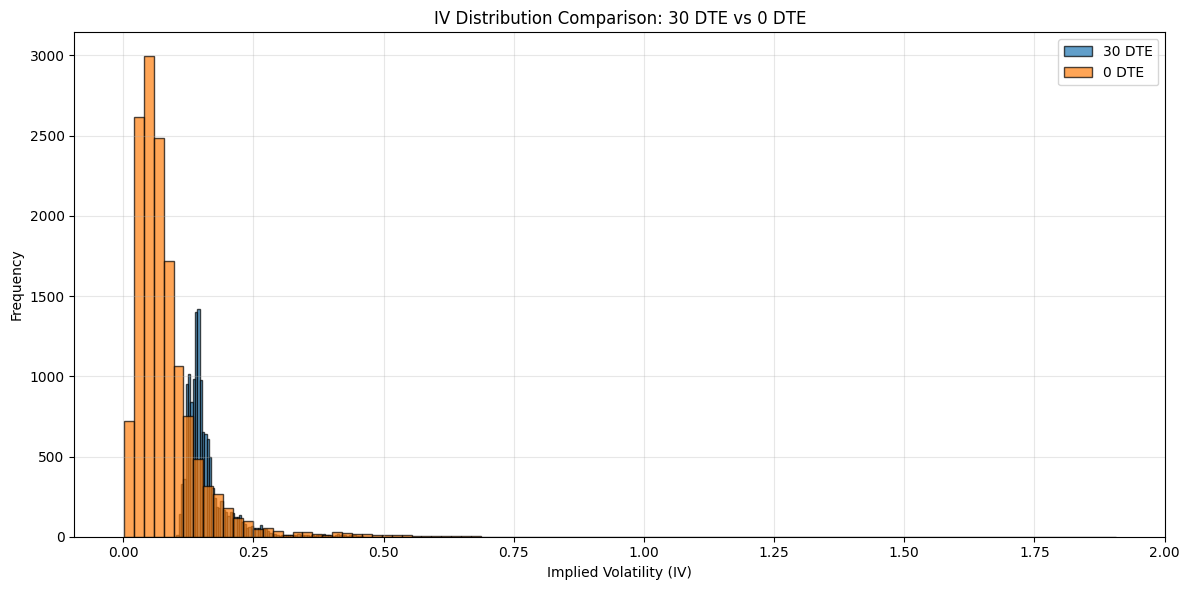

In [3]:
# Load the train features data
#train_file = r"c:\Users\Franswa\Documents\TickStream\Option data dash\clean_data_12\train_features_5m_clean.parquet"
train_file = r"c:\Users\Franswa\Documents\TickStream\Option data dash\34_features_newvol\train_features_5m_clean.parquet"
df_train = pd.read_parquet(train_file)
# Ensure the datetime column is the index so time-based grouping/resampling works
if df_train.index.dtype == 'int64' or isinstance(df_train.index, pd.RangeIndex):
    df_train.set_index('bar5', inplace=True)

# The file contains aggregated features, including prev_atm_iv_30dte and prev_atm_iv_0dte
# Print some statistics
print("30 DTE IV Statistics:")
print(df_train['prev_atm_iv_30dte'].describe())
print("\n0 DTE IV Statistics:")
print(df_train['prev_atm_iv_0dte'].describe())

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(df_train['prev_atm_iv_30dte'].dropna(), bins=100, alpha=0.7, label='30 DTE', edgecolor='black')
plt.hist(df_train['prev_atm_iv_0dte'].dropna(), bins=100, alpha=0.7, label='0 DTE', edgecolor='black')
plt.title('IV Distribution Comparison: 30 DTE vs 0 DTE')
plt.xlabel('Implied Volatility (IV)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

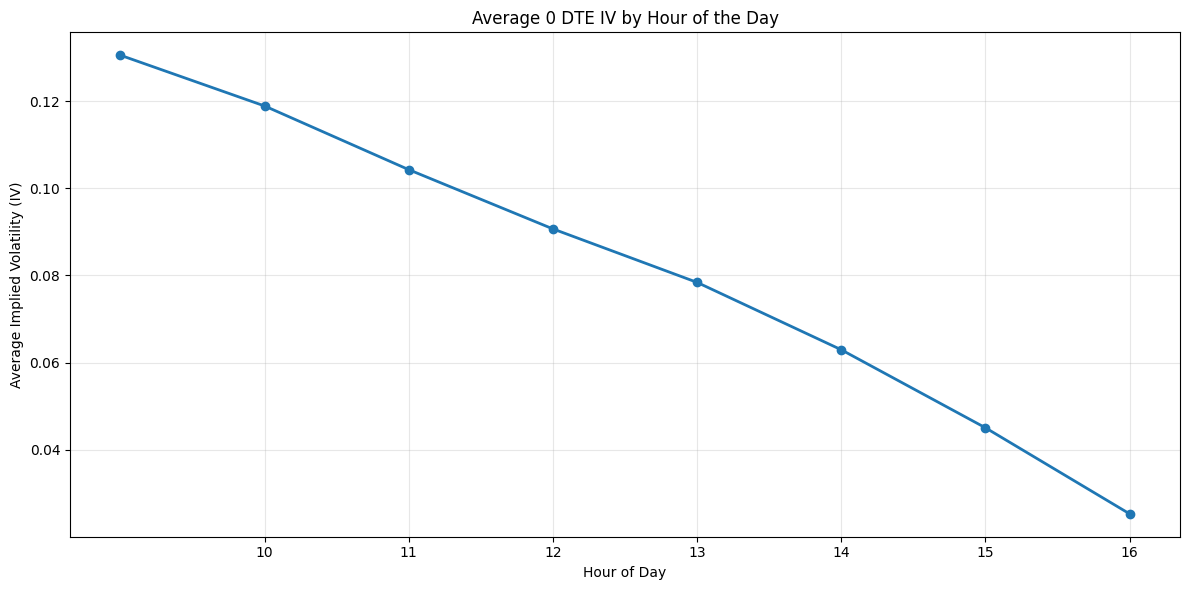

Average 0 DTE IV by Hour:
Hour 9: 0.1306
Hour 10: 0.1189
Hour 11: 0.1043
Hour 12: 0.0907
Hour 13: 0.0784
Hour 14: 0.0629
Hour 15: 0.0450
Hour 16: 0.0253


In [4]:
# Group by hour of the day and calculate mean IV for 0 DTE
hourly_iv = df_train.groupby(df_train.index.hour)['prev_atm_iv_0dte'].mean()

# Plot the hourly IV
plt.figure(figsize=(12, 6))
plt.plot(hourly_iv.index, hourly_iv.values, marker='o', linestyle='-', linewidth=2)
plt.title('Average 0 DTE IV by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Implied Volatility (IV)')
plt.xticks(range(10, 17))  # Assuming trading hours 10-16
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the hourly averages
print("Average 0 DTE IV by Hour:")
for hour, iv in hourly_iv.items():
    print(f"Hour {hour}: {iv:.4f}")

Total Option Volume Statistics:
count    1.422900e+04
mean     9.293760e+05
std      4.133495e+05
min      2.063000e+03
25%      6.203620e+05
50%      9.068410e+05
75%      1.214609e+06
max      2.766870e+06
Name: prev_total_option_volume, dtype: float64

Total Option Open Interest Statistics:
count    1.422900e+04
mean     3.705188e+06
std      7.823294e+05
min      3.369760e+05
25%      3.138182e+06
50%      3.695858e+06
75%      4.219296e+06
max      6.900672e+06
Name: prev_total_option_oi, dtype: float64


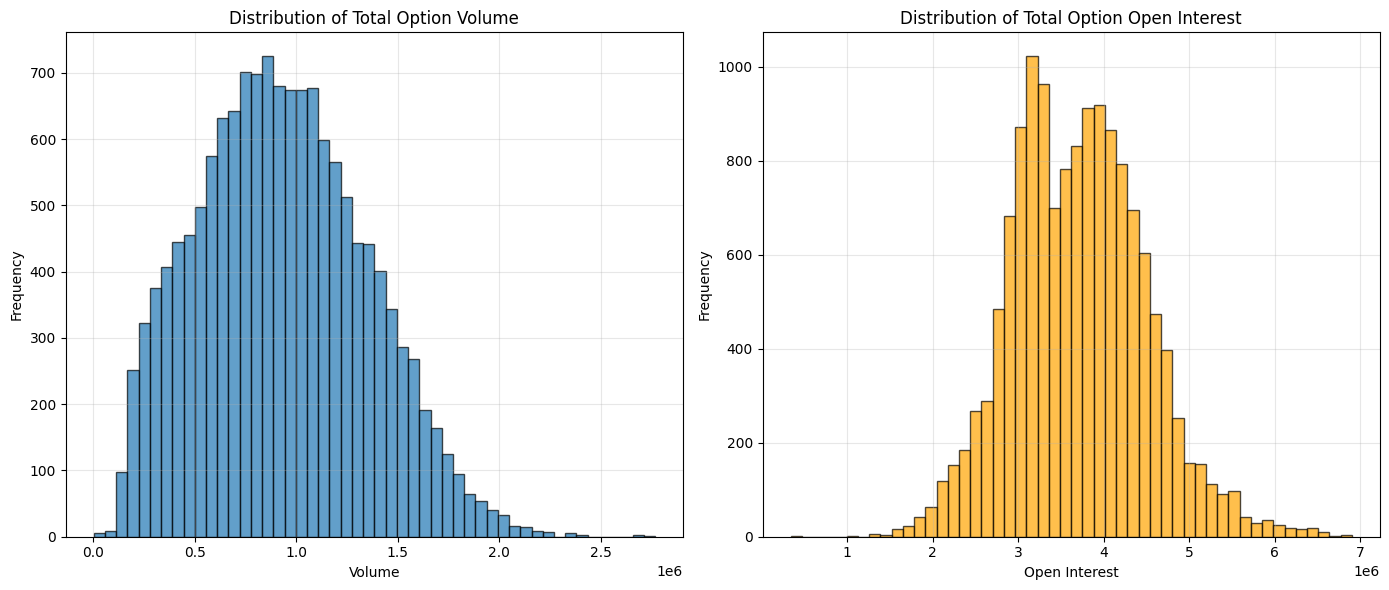

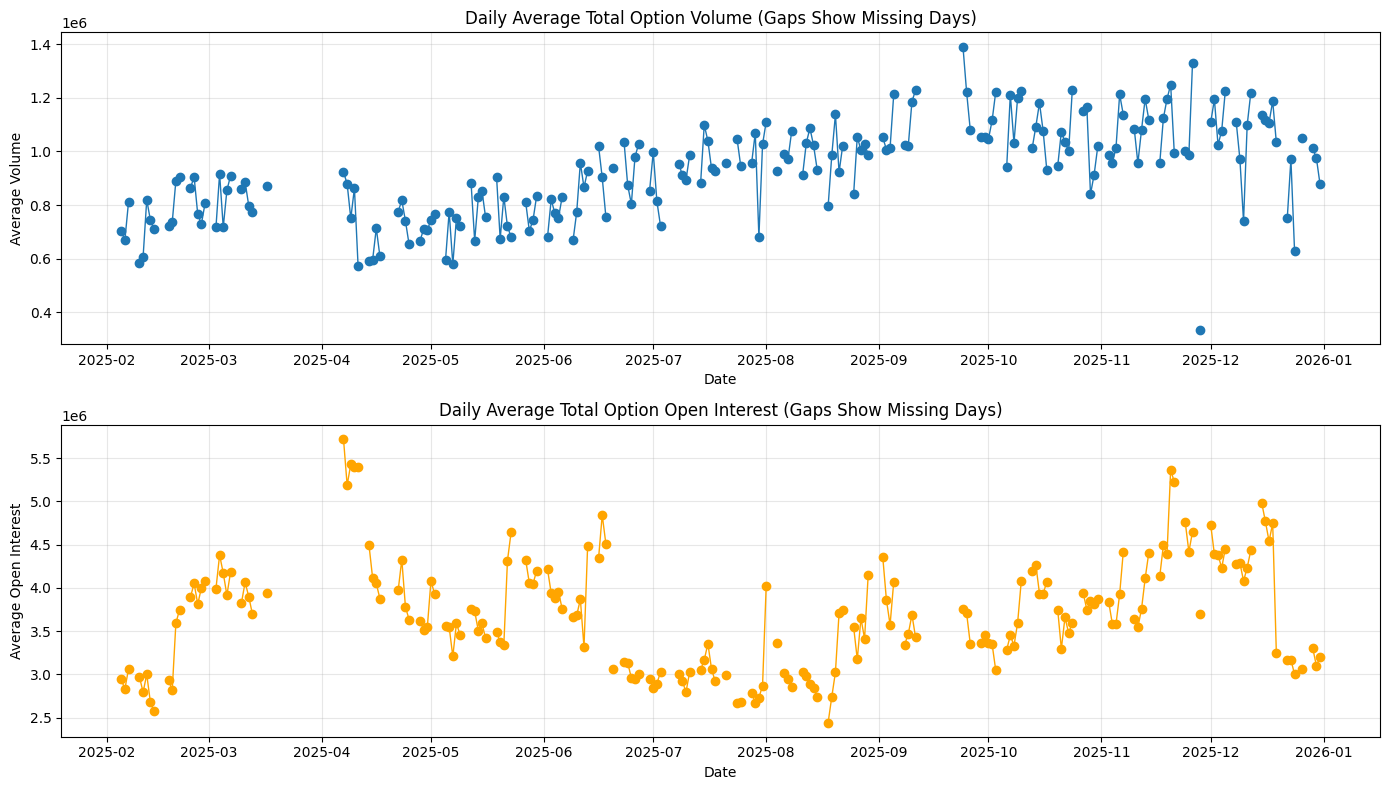

In [5]:

# Print statistics for volume and OI
print("Total Option Volume Statistics:")
print(df_train['prev_total_option_volume'].describe())
print("\nTotal Option Open Interest Statistics:")
print(df_train['prev_total_option_oi'].describe())

# Plot histograms of volume and OI
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(df_train['prev_total_option_volume'].dropna(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Option Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df_train['prev_total_option_oi'].dropna(), bins=50, alpha=0.7, edgecolor='black', color='orange')
plt.title('Distribution of Total Option Open Interest')
plt.xlabel('Open Interest')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resample to daily averages to show gaps where days are missing
daily_data = df_train.resample('D').mean()[['prev_total_option_volume', 'prev_total_option_oi']]

# Plot daily averages over time (gaps will be visible)
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(daily_data.index, daily_data['prev_total_option_volume'], marker='o', linestyle='-', linewidth=1)
plt.title('Daily Average Total Option Volume (Gaps Show Missing Days)')
plt.xlabel('Date')
plt.ylabel('Average Volume')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(daily_data.index, daily_data['prev_total_option_oi'], marker='o', linestyle='-', linewidth=1, color='orange')
plt.title('Daily Average Total Option Open Interest (Gaps Show Missing Days)')
plt.xlabel('Date')
plt.ylabel('Average Open Interest')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

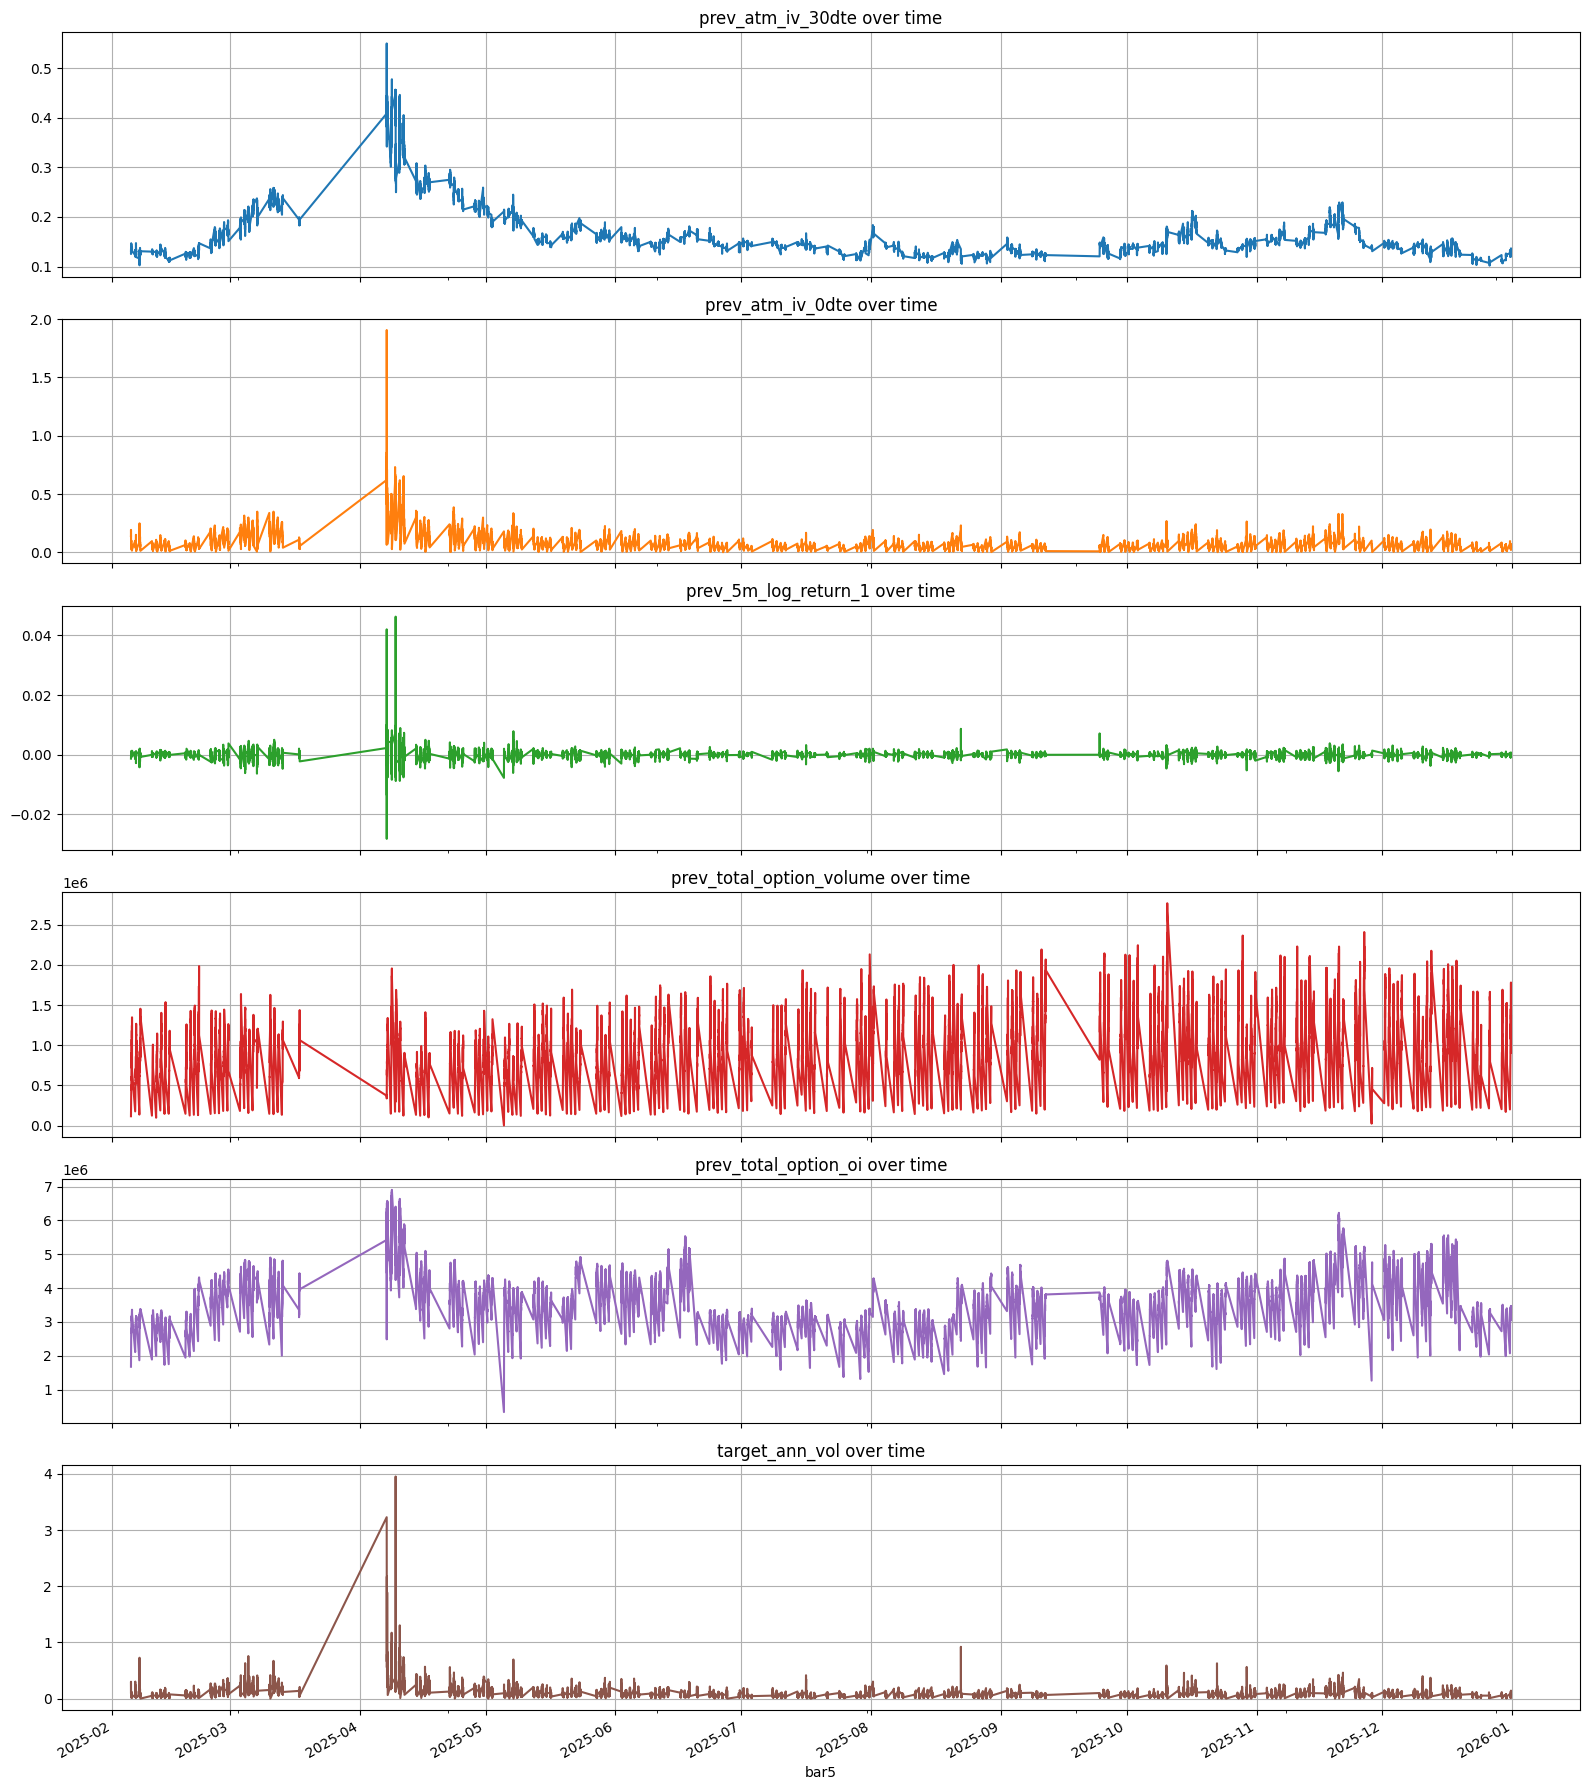

In [6]:
# Ensure time-based plotting uses the datetime index
if 'bar5' in df_train.columns:
    df_train = df_train.set_index('bar5')
    df_train.index = pd.to_datetime(df_train.index)

plot_cols = [
    'prev_atm_iv_30dte',
    'prev_atm_iv_0dte',
    'prev_5m_log_return_1',
    'prev_total_option_volume',
    'prev_total_option_oi',
    'target_ann_vol'
]
plot_cols = [c for c in plot_cols if c in df_train.columns]

if plot_cols:
    df_train[plot_cols].plot(
        subplots=True,
        figsize=(16, 3 * len(plot_cols)),
        title=[f'{col} over time' for col in plot_cols],
        grid=True,
        legend=False
    )
    plt.tight_layout()
    plt.show()
else:
    print('No relevant plot columns found in df_train.')